In [4]:
import matplotlib.pyplot as plt

# Configure matplotlib for editable text in Inkscape SVG exports
plt.rcParams.update({'text.usetex': False, 'svg.fonttype': 'none'})

In [5]:
from scipy import stats
import numpy as np
import xarray as xr
import os
import pickle

# Re-initialize lists to collect raw CEREBON and CEREBOFF values
all_tvb_cerebon = []
all_tvb_cereboff = []
all_cosim_cerebon = []
all_cosim_cereboff = []

# Dummy load_pickled_dict function (re-added for self-containment)
def load_pickled_dict(filepath):
    """Dummy function to load pickled data."""
    print(f"Loading data from: {filepath}")
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data

# Define the GAMMA frequency range (25-60 Hz inclusive)
min_gamma_freq = 25.0
max_gamma_freq = 60.0
BASEPATH = "/content/" # Files are directly in /content/

# Re-run the data processing loop to extract CEREBON and CEREBOFF values
for iM, mode in enumerate(["TVB", "COSIM"]):
    # Correcting the file path for COSIM data from COH_cosim.pkl to COH_cosimnew.pkl
    current_pkl_file = os.path.join(BASEPATH, "COH.pkl") if mode == "TVB" else os.path.join(BASEPATH, "COH_cosimnew.pkl")
    loaded_data_dict = load_pickled_dict(current_pkl_file)

    processed_coords = {}
    for k, v in loaded_data_dict['coords'].items():
        if isinstance(v, dict) and 'data' in v:
            processed_coords[k] = v['data']
        else:
            processed_coords[k] = v

    COH_full_data_array = xr.DataArray(
        loaded_data_dict['data'],
        coords=processed_coords,
        dims=loaded_data_dict['dims']
    )

    COH_G6_Gamma_band = COH_full_data_array.sel(G=6, Frequency=slice(min_gamma_freq, max_gamma_freq))
    COH_G6_Gamma = COH_G6_Gamma_band.mean(dim='Frequency')

    cerebon_values_2D = COH_G6_Gamma.sel(Condition='CEREBON')
    cereboff_values_2D = COH_G6_Gamma.sel(Condition='CEREBOFF')

    # The original 0ed51d93 had `mean(dim='Connections')` before t-test.
    # However, the user's initial main plot 8937c7b6 had M1S1 selection. Let's make this consistent.
    # For the t-test, it makes sense to use the same M1S1 average as the main coherence drop calculation.
    M1S1r = 'Right Primary motor area - Right Primary somatosensory area, barrel field'
    M1S1l = 'Left Primary motor area - Left Primary somatosensory area, barrel field'
    M1S1 = [M1S1r, M1S1l]

    cerebon_per_sim = cerebon_values_2D.sel(Connections=M1S1).mean(dim='Connections')
    cereboff_per_sim = cereboff_values_2D.sel(Connections=M1S1).mean(dim='Connections')

    if mode == "TVB":
        all_tvb_cerebon.extend(cerebon_per_sim.values)
        all_tvb_cereboff.extend(cereboff_per_sim.values)
    else:
        all_cosim_cerebon.extend(cerebon_per_sim.values)
        all_cosim_cereboff.extend(cereboff_per_sim.values)

# Ensure all_tvb_cerebon, all_tvb_cereboff, all_cosim_cerebon, all_cosim_cereboff are numpy arrays
tvb_cerebon_arr = np.array(all_tvb_cerebon)
tvb_cereboff_arr = np.array(all_tvb_cereboff)
cosim_cerebon_arr = np.array(all_cosim_cerebon)
cosim_cereboff_arr = np.array(all_cosim_cereboff)

alpha = 0.05 # Significance level

print("--- T-test results for CEREBON vs CEREBOFF ---")

# Perform t-test for TVB
t_stat_tvb, p_value_tvb = stats.ttest_ind(tvb_cerebon_arr, tvb_cereboff_arr, equal_var=False) # Welch's t-test assuming unequal variances
print(f"\nTVB: CEREBON vs CEREBOFF")
print(f"  Mean CEREBON: {tvb_cerebon_arr.mean():.4f}")
print(f"  Mean CEREBOFF: {tvb_cereboff_arr.mean():.4f}")
print(f"  T-statistic: {t_stat_tvb:.3f}")
print(f"  P-value: {p_value_tvb:.4f}")
if p_value_tvb < alpha:
    print(f"  Result: Significant difference (p < {alpha})")
else:
    print(f"  Result: No significant difference (p >= {alpha})")

# Perform t-test for COSIM
t_stat_cosim, p_value_cosim = stats.ttest_ind(cosim_cerebon_arr, cosim_cereboff_arr, equal_var=False) # Welch's t-test
print(f"\nCOSIM: CEREBON vs CEREBOFF")
print(f"  Mean CEREBON: {cosim_cerebon_arr.mean():.4f}")
print(f"  Mean CEREBOFF: {cosim_cereboff_arr.mean():.4f}")
print(f"  T-statistic: {t_stat_cosim:.3f}")
print(f"  P-value: {p_value_cosim:.4f}")
if p_value_cosim < alpha:
    print(f"  Result: Significant difference (p < {alpha})")
else:
    print(f"  Result: No significant difference (p >= {alpha})")


Loading data from: /content/COH.pkl
Loading data from: /content/COH_cosimnew.pkl
--- T-test results for CEREBON vs CEREBOFF ---

TVB: CEREBON vs CEREBOFF
  Mean CEREBON: 0.1680
  Mean CEREBOFF: 0.0760
  T-statistic: 18.115
  P-value: 0.0000
  Result: Significant difference (p < 0.05)

COSIM: CEREBON vs CEREBOFF
  Mean CEREBON: 0.1565
  Mean CEREBOFF: 0.0682
  T-statistic: 12.289
  P-value: 0.0000
  Result: Significant difference (p < 0.05)


Plot saved as coherence_comparison.svg


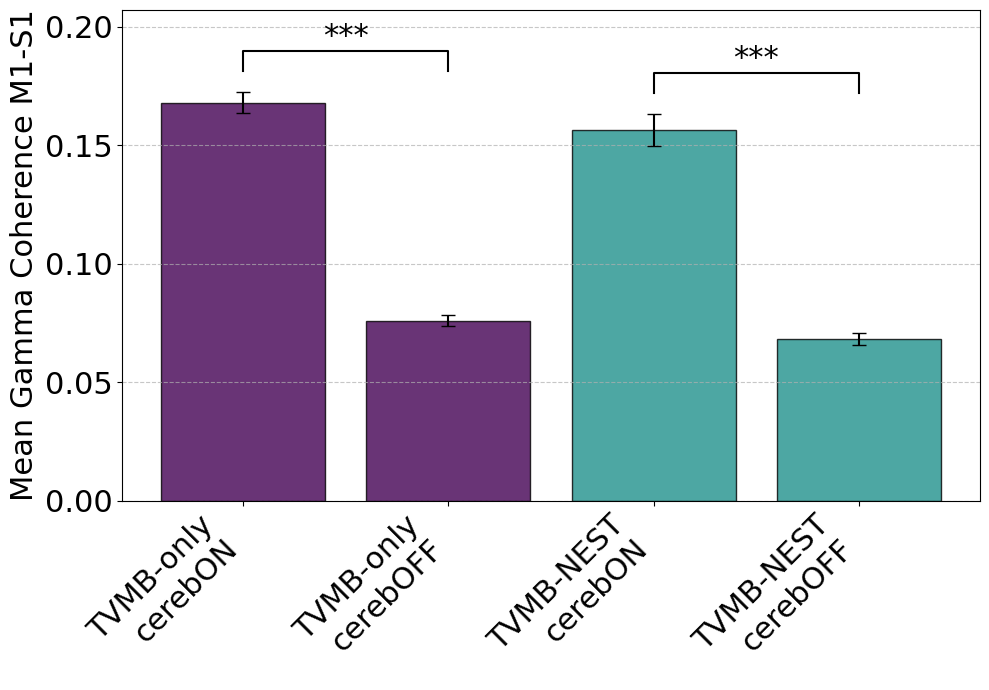

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats # For stats.sem

# Data from previous calculations (assuming these are available in the kernel)
# tvb_cerebon_arr, tvb_cereboff_arr, cosim_cerebon_arr, cosim_cereboff_arr
# p_value_tvb, p_value_cosim

# User provided Popa et al. Gamma data
popa_gamma_control_mean = 0.044
popa_gamma_control_std = 0.019
popa_gamma_muscimol_mean = 0.047
popa_gamma_muscimol_std = 0.011

# Calculate means and standard errors of the mean (SEM)
means = [
    tvb_cerebon_arr.mean(),
    tvb_cereboff_arr.mean(),
    cosim_cerebon_arr.mean(),
    cosim_cereboff_arr.mean()
]

sems = [
    stats.sem(tvb_cerebon_arr),
    stats.sem(tvb_cereboff_arr),
    stats.sem(cosim_cerebon_arr),
    stats.sem(cosim_cereboff_arr)
]

labels = [
    'TVMB-only\ncerebON', 'TVMB-only\ncerebOFF',
    'TVMB-NEST\ncerebON', 'TVMB-NEST\ncerebOFF'
]
x_positions = np.arange(len(labels))

# Significance levels
alpha = 0.05
significance_tvb = p_value_tvb < alpha
significance_cosim = p_value_cosim < alpha

# Plotting
fig, ax = plt.subplots(figsize=(10, 7)) # Increased figure size for more bars

# Define colors for TVB and COSIM, similar to previous plots
# Using viridis colormap for consistency
# cmap = plt.colormaps.get_cmap('viridis') # Removed as explicit hex codes are used
tvb_color = '#440154' # Darker blue/purple - User defined
cosim_color = '#21918C' # Blue-green - User defined
popa_color = '#3B528B' # Closer to blue/cyan for Exp. - User defined

colors = [
    tvb_color, tvb_color,
    cosim_color, cosim_color
]

ax.bar(x_positions, means, yerr=sems, capsize=5, color=colors, alpha=0.8, edgecolor='black') # yerr=sems to add back error bars

# Add significance indicators
def add_significance_line(ax, x1, x2, y_start, h, p_value, alpha):
    if p_value < alpha:
        star = '*' * (int(-np.log10(p_value)) if p_value > 0 else 3) # Max 3 stars for p < 0.001
        if p_value < 0.001: star = '***'
        elif p_value < 0.01: star = '**'
        elif p_value < 0.05: star = '*'

        ax.plot([x1, x1, x2, x2], [y_start, y_start + h, y_start + h, y_start], lw=1.5, c='k')
        ax.text((x1 + x2) * .5, y_start + h, star, ha='center', va='bottom', color='k', fontsize=22) # Increased fontsize

# Calculate placement for significance lines
# Get the overall max y-value including error bars
y_max_overall = max(np.array(means) + np.array(sems))

# Determine the y-position for the TVB significance indicator
y_tvb_sig_level = max(means[0] + sems[0], means[1] + sems[1])
y_tvb_sig_start = y_tvb_sig_level + y_max_overall * 0.05 # Reverted to previous spacing
h_tvb_sig = y_max_overall * 0.05 # Reverted to previous spacing

# Determine the y-position for the COSIM significance indicator
y_cosim_sig_level = max(means[2] + sems[2], means[3] + sems[3])
y_cosim_sig_start = y_cosim_sig_level + y_max_overall * 0.05 # Reverted to previous spacing
h_cosim_sig = y_max_overall * 0.05 # Reverted to previous spacing

# TVB significance
if significance_tvb:
    add_significance_line(ax, x_positions[0], x_positions[1], y_tvb_sig_start, h_tvb_sig, p_value_tvb, alpha)

# COSIM significance
if significance_cosim:
    add_significance_line(ax, x_positions[2], x_positions[3], y_cosim_sig_start, h_cosim_sig, p_value_cosim, alpha)

# No significance test requested for Exp. cerebON vs Exp. cerebOFF, so no line added here.

ax.set_ylabel('Mean Gamma Coherence M1-S1', fontsize=22) # Increased fontsize
#ax.set_title('Mean Coherence Comparison: CEREBON vs CEREBOFF', fontsize=14, fontweight='bold') # Title removed previously
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=22) # Changed rotation back to 45 and ha to right
ax.tick_params(axis='y', labelsize=22) # Increased fontsize
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Extend y-axis limits to accommodate significance bars and stars
ax.set_ylim(bottom=0, top=y_max_overall * 1.2) # Adjusted top limit slightly for new spacing

plt.tight_layout()
plt.savefig('coherence_comparison.svg', bbox_inches='tight') # Changed to SVG
print('Plot saved as coherence_comparison.svg') # Updated print statement
plt.show() # Keep show here

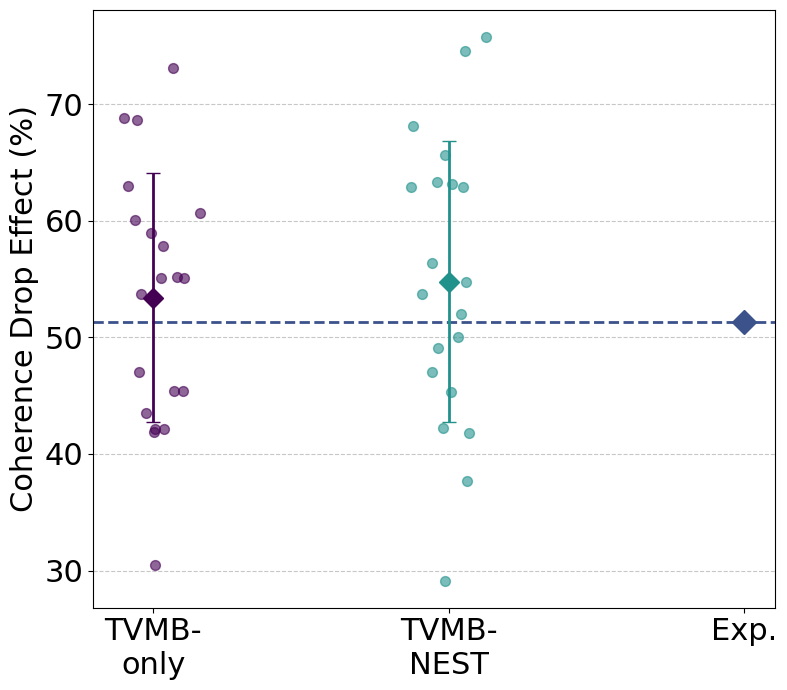

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import xarray as xr
import os
import pickle
import pandas as pd

# --- BEGIN: Code to ensure variables are defined (extracted from previous cells) ---

# Dummy load_pickled_dict function
def load_pickled_dict(filepath):
    """Dummy function to load pickled data."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data

# Dummy config and get_freq (if needed by other functions, keeping for completeness)
config = {}
def dummy_get_freq_func(data_array, label_str, config_dict):
    return data_array
get_freq = {"GAMMA": dummy_get_freq_func}

# Define constants needed for data processing
BASEPATH = "/content/"
min_gamma_freq = 25.0
max_gamma_freq = 60.0
M1S1r_conn = 'Right Primary motor area - Right Primary somatosensory area, barrel field'
M1S1l_conn = 'Left Primary motor area - Left Primary somatosensory area, barrel field'

# Initialize lists to collect raw CEREBON and CEREBOFF values for each hemispheric group
all_tvb_right_cerebon = []
all_tvb_right_cereboff = []
all_tvb_left_cerebon = []
all_tvb_left_cereboff = []
all_cosim_right_cerebon = []
all_cosim_right_cereboff = []
all_cosim_left_cerebon = []
all_cosim_left_cereboff = []

# Initialize lists for hemispheric coherence drop ratios (FIXED: Added these initializations)
all_tvb_right_cohdiff_ratios = []
all_tvb_left_cohdiff_ratios = []
all_cosim_right_cohdiff_ratios = []
all_cosim_left_cohdiff_ratios = []

# Re-extract Popa Data (copied from cell 10e4d8a0 or 50525f9f for completeness)
PopaEtAltargetMin = np.array([-6.93389304, -6.93389304, -24.14843798, -24.14843798,
          6.87260327,   6.87260327])
PopaEtAltargetMean = np.array([21.82914281, 21.82914281, 13.3813505 , 13.3813505 , 51.31657516,
        51.31657516])
PopaEtAltargetMax = np.array([39.61079797, 39.61079797, 61.96537027, 61.96537027, 73.82038146,
        73.82038146])

# For GAMMA band, the user specified values from index 4 onwards
popa_min = PopaEtAltargetMin[4:] # This is effectively [6.87, 6.87]
popa_mean = PopaEtAltargetMean[4:] # This is effectively [51.31, 51.31]
popa_max = PopaEtAltargetMax[4:] # This is effectively [73.82, 73.82]

# To have a single mean, min, max for plotting, let's take the first element
popa_mean_gamma = popa_mean[0]
popa_min_gamma = popa_min[0]
popa_max_gamma = popa_max[0]
# --- END NEW Popa Data ---


# Re-run data processing to get hemispheric coherence drop ratios (from cell 2072b906)
for iM, mode in enumerate(["TVB", "COSIM"]):
    if mode == "TVB":
        current_pkl_file = os.path.join(BASEPATH, "COH.pkl")
    else:
        current_pkl_file = os.path.join(BASEPATH, "COH_cosimnew.pkl")

    loaded_data_dict = load_pickled_dict(current_pkl_file)

    processed_coords = {}
    for k, v in loaded_data_dict['coords'].items():
        if isinstance(v, dict) and 'data' in v:
            processed_coords[k] = v['data']
        else:
            processed_coords[k] = v

    COH_full_data_array = xr.DataArray(
        loaded_data_dict['data'],
        coords=processed_coords,
        dims=loaded_data_dict['dims']
    )

    COH_G6_Gamma_band = COH_full_data_array.sel(G=6, Frequency=slice(min_gamma_freq, max_gamma_freq))
    COH_G6_Gamma = COH_G6_Gamma_band.mean(dim='Frequency')

    cerebon_values_2D = COH_G6_Gamma.sel(Condition='CEREBON')
    cereboff_values_2D = COH_G6_Gamma.sel(Condition='CEREBOFF')

    for conn_name in [M1S1r_conn, M1S1l_conn]:
        cerebon_per_sim_conn = cerebon_values_2D.sel(Connections=conn_name)
        cereboff_per_sim_conn = cereboff_values_2D.sel(Connections=conn_name)

        coh_diff_ratios_for_conn = 100 * (cerebon_per_sim_conn - cereboff_per_sim_conn) / cerebon_per_sim_conn

        if mode == "TVB":
            if conn_name == M1S1r_conn:
                all_tvb_right_cohdiff_ratios.extend(coh_diff_ratios_for_conn.values)
            elif conn_name == M1S1l_conn:
                all_tvb_left_cohdiff_ratios.extend(coh_diff_ratios_for_conn.values)
        else:
            if conn_name == M1S1r_conn:
                all_cosim_right_cohdiff_ratios.extend(coh_diff_ratios_for_conn.values)
            elif conn_name == M1S1l_conn:
                all_cosim_left_cohdiff_ratios.extend(coh_diff_ratios_for_conn.values)

# Pool hemispheric data (from cell 97b6d6cc)
all_tvb_cohdiff_ratios = all_tvb_right_cohdiff_ratios + all_tvb_left_cohdiff_ratios
all_cosim_cohdiff_ratios = all_cosim_right_cohdiff_ratios + all_cosim_left_cohdiff_ratios

# Convert pooled lists to NumPy arrays (from cell 15dae169)
tvb_coh_drop_arr_pooled = np.array(all_tvb_cohdiff_ratios)
cosim_coh_drop_arr_pooled = np.array(all_cosim_cohdiff_ratios)

# --- END: Code to ensure variables are defined ---

# Define x-axis positions for the two pooled groups and Popa
x_tvb_pooled = 1
x_cosim_pooled = 2
x_popa = 3

# Calculate means and Standard Deviations for pooled TVB and COSIM
# Pooled TVB
mean_tvb_pooled = np.mean(tvb_coh_drop_arr_pooled)
std_dev_tvb_pooled = np.std(tvb_coh_drop_arr_pooled)

# Pooled COSIM
mean_cosim_pooled = np.mean(cosim_coh_drop_arr_pooled)
std_dev_cosim_pooled = np.std(cosim_coh_drop_arr_pooled)

# Set up colors using hex codes
tvb_color = '#440154' # Darker blue/purple
cosim_color = '#21918C' # Blue-green
popa_color = '#3B528B' # Closer to blue/cyan for Exp.

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# 1. For Pooled TVB:
# Plot individual scatter points with jitter
ax.scatter(np.full(len(tvb_coh_drop_arr_pooled), x_tvb_pooled) + np.random.normal(0, 0.08, size=len(tvb_coh_drop_arr_pooled)),
           tvb_coh_drop_arr_pooled, color=tvb_color, alpha=0.6, label='Pooled TVB Individual Runs', s=50, zorder=2)
# Plot mean and Standard Deviation
ax.errorbar(x_tvb_pooled, mean_tvb_pooled, yerr=std_dev_tvb_pooled,
            fmt='D', color=tvb_color, capsize=5, label='Pooled TVB Mean & Std Dev', markersize=10, elinewidth=2, zorder=3)

# 2. For Pooled COSIM:
# Plot individual scatter points with jitter
ax.scatter(np.full(len(cosim_coh_drop_arr_pooled), x_cosim_pooled) + np.random.normal(0, 0.08, size=len(cosim_coh_drop_arr_pooled)),
           cosim_coh_drop_arr_pooled, color=cosim_color, alpha=0.6, label='Pooled COSIM Individual Runs', s=50, zorder=2)
# Plot mean and Standard Deviation
ax.errorbar(x_cosim_pooled, mean_cosim_pooled, yerr=std_dev_cosim_pooled,
            fmt='D', color=cosim_color, capsize=5, label='Pooled COSIM Mean & Std Dev', markersize=10, elinewidth=2, zorder=3)

# 3. For Popa:
# Plot mean as a diamond marker
ax.plot(x_popa, popa_mean_gamma, 'D', color=popa_color, markersize=12, zorder=3) # Removed label
# Removed plotting of Popa's min and max, and the connecting line

# Removed text labels next to Popa's mean for clarity as requested
# font_size_values = 18
# ax.text(x_popa - 0.1, popa_mean_gamma, 'Mean', color=popa_color, verticalalignment='center', horizontalalignment='right', fontsize=font_size_values)
# Removed text labels for Popa's min and max

# Add horizontal line for Popa's mean
ax.axhline(y=popa_mean_gamma, color=popa_color, linestyle='--', linewidth=2, zorder=1)

# Set x-axis ticks and labels
ax.set_xticks([x_tvb_pooled, x_cosim_pooled, x_popa])
ax.set_xticklabels(['TVMB-\nonly', 'TVMB-\nNEST', 'Exp.'], fontsize=22) # Changed 'Popa et al.' to 'Exp.'

# Add labels and title
ax.set_ylabel('Coherence Drop Effect (%)', fontsize=22) # Increased font size
# ax.set_title('Coherence Drop Effect Comparison (Pooled Hemispheric Data)', fontsize=20, fontweight='bold') # Removed title

# Adjust y-axis tick params
ax.tick_params(axis='y', labelsize=22) # Increased font size

# Add grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Removed legend generation and display
# ax.legend(simplified_handles, simplified_labels, loc='lower left', fontsize=18)

# Adjust layout and show plot
plt.tight_layout()
plt.savefig('coherence_drop_comparison.png', dpi=600, bbox_inches='tight') # Changed filename and increased dpi
plt.savefig('coherence_drop_comparison.svg', bbox_inches='tight') # Changed to SVG
plt.show()

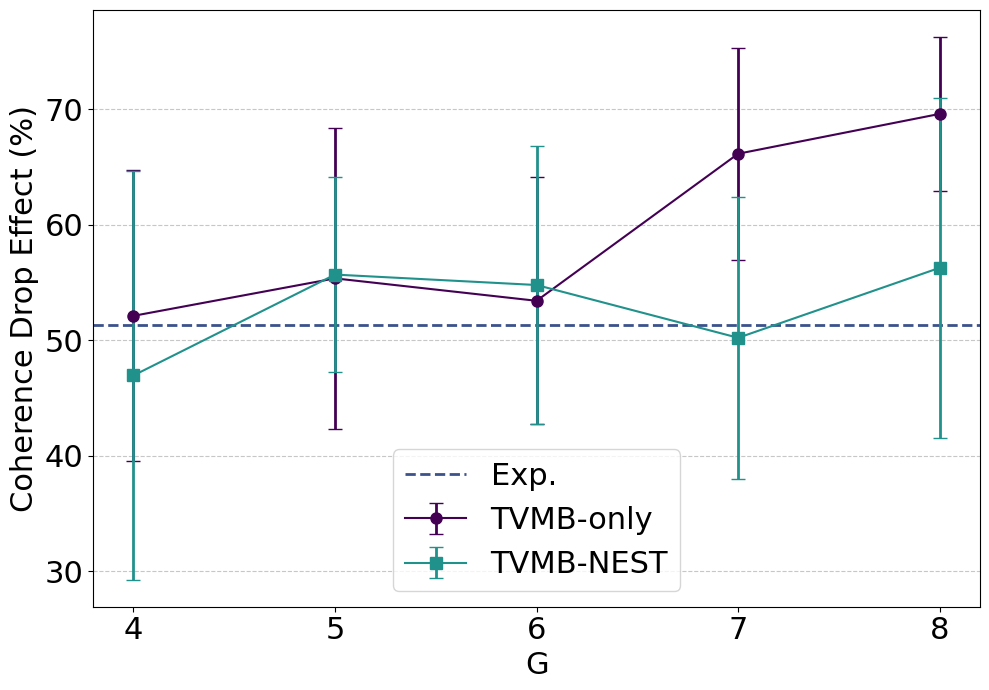

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import xarray as xr
import os
import pickle
import pandas as pd

# --- BEGIN: Code to ensure variables are defined (extracted from previous cells for self-containment) ---

# Dummy load_pickled_dict function
def load_pickled_dict(filepath):
    """Dummy function to load pickled data."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data

# Define constants needed for data processing
BASEPATH = "/content/"
min_gamma_freq = 25.0
max_gamma_freq = 60.0
M1S1r_conn = 'Right Primary motor area - Right Primary somatosensory area, barrel field'
M1S1l_conn = 'Left Primary motor area - Left Primary somatosensory area, barrel field'

# Re-extract Popa Data (copied from cell 3d7c98ba for completeness)
# These arrays contain data for multiple frequency bands; we'll use the Gamma-specific ones.
PopaEtAltargetMin = np.array([-6.93389304, -6.93389304, -24.14843798, -24.14843798,
          6.87260327,   6.87260327])
PopaEtAltargetMean = np.array([21.82914281, 21.82914281, 13.3813505 , 13.3813505 , 51.31657516,
        51.31657516])
PopaEtAltargetMax = np.array([39.61079797, 39.61079797, 61.96537027, 61.96537027, 73.82038146,
        73.82038146])

# For GAMMA band, the user specified values from index 4 onwards in previous cells
popa_min_gamma = PopaEtAltargetMin[4]
popa_mean_gamma = PopaEtAltargetMean[4]
popa_max_gamma = PopaEtAltargetMax[4]
# --- END: Code to ensure variables are defined ---


# Initialize data structures to store results for plotting
all_g_values = []
tvb_mean_coh_drops = []
tvb_std_coh_drops = []
cosim_mean_coh_drops = []
cosim_std_coh_drops = []

# Get the list of G values from the data (assuming COH.pkl contains all G values)
temp_data_dict = load_pickled_dict(os.path.join(BASEPATH, "COH.pkl"))
g_coords = temp_data_dict['coords']['G']['data']
all_g_values = sorted(list(g_coords))

for current_G in all_g_values:
    # Lists to collect coherence drop ratios for current G value and both connections/repetitions
    current_g_tvb_ratios = []
    current_g_cosim_ratios = []

    for mode_idx, mode in enumerate(["TVB", "COSIM"]):
        current_pkl_file = os.path.join(BASEPATH, "COH.pkl") if mode == "TVB" else os.path.join(BASEPATH, "COH_cosimnew.pkl")
        loaded_data_dict = load_pickled_dict(current_pkl_file)

        processed_coords = {}
        for k, v in loaded_data_dict['coords'].items():
            if isinstance(v, dict) and 'data' in v:
                processed_coords[k] = v['data']
            else:
                processed_coords[k] = v

        COH_full_data_array = xr.DataArray(
            loaded_data_dict['data'],
            coords=processed_coords,
            dims=loaded_data_dict['dims']
        )

        # Select the current G value AND the Gamma frequency band
        COH_current_G_Gamma_band = COH_full_data_array.sel(G=current_G, Frequency=slice(min_gamma_freq, max_gamma_freq))
        COH_current_G_Gamma = COH_current_G_Gamma_band.mean(dim='Frequency')

        cerebon_values_2D = COH_current_G_Gamma.sel(Condition='CEREBON')
        cereboff_values_2D = COH_current_G_Gamma.sel(Condition='CEREBOFF')

        conn_ratios = [] # To collect ratios for both M1S1 connections for the current mode and G
        for conn_name in [M1S1r_conn, M1S1l_conn]:
            cerebon_per_sim_conn = cerebon_values_2D.sel(Connections=conn_name)
            cereboff_per_sim_conn = cereboff_values_2D.sel(Connections=conn_name)
            coh_diff_ratios_for_conn = 100 * (cerebon_per_sim_conn - cereboff_per_sim_conn) / cerebon_per_sim_conn
            conn_ratios.extend(coh_diff_ratios_for_conn.values)

        if mode == "TVB":
            current_g_tvb_ratios.extend(conn_ratios)
        else:
            current_g_cosim_ratios.extend(conn_ratios)

    # After processing both modes for the current G, calculate mean and std dev
    tvb_mean_coh_drops.append(np.mean(current_g_tvb_ratios))
    tvb_std_coh_drops.append(np.std(current_g_tvb_ratios))
    cosim_mean_coh_drops.append(np.mean(current_g_cosim_ratios))
    cosim_std_coh_drops.append(np.std(current_g_cosim_ratios))

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Define colors using hex codes
tvb_color = '#440154'
cosim_color = '#21918C'
popa_color = '#3B528B'

# Plot TVB results
ax.errorbar(all_g_values, tvb_mean_coh_drops, yerr=tvb_std_coh_drops,
            fmt='-o', color=tvb_color, capsize=5, label='TVMB-only', markersize=8, elinewidth=2, zorder=3)

# Plot COSIM results
ax.errorbar(all_g_values, cosim_mean_coh_drops, yerr=cosim_std_coh_drops,
            fmt='-s', color=cosim_color, capsize=5, label='TVMB-NEST', markersize=8, elinewidth=2, zorder=3)

# Plot Popa's mean as a horizontal line
ax.axhline(y=popa_mean_gamma, color=popa_color, linestyle='--', linewidth=2, label='Exp.', zorder=1)
# Plot Popa's min/max range as a shaded area
# ax.fill_between(x=all_g_values, y1=popa_min_gamma, y2=popa_max_gamma, color=popa_color, alpha=0.1, label='Exp. Range', zorder=0)

ax.set_ylabel('Coherence Drop Effect (%)', fontsize=22)
ax.set_xlabel('G', fontsize=22)
# ax.set_title('Coherence Drop Effect Across G Values (Gamma Band)', fontsize=18, fontweight='bold')
ax.set_xticks(all_g_values)
ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(fontsize=22, loc='lower center')

plt.tight_layout()

# Save the figure as a high-quality PNG
plt.savefig('coherence_drop_across_G_values.png', dpi=300)

plt.show()